In [1]:
# ============================================================
# Customer Support Intelligence System
# CPU-only Notebook
# Dataset folder:
# D:\Deeplaksh\Personal file\NLP dataset
# ============================================================

import os
import re
import json
import time
import pickle
import warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# ============================================================
# Configuration
# ============================================================

DATA_DIR = r"D:\Deeplaksh\Personal file\NLP dataset"

ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

MAX_ROWS = None          # Set to an integer like 5000 for faster experiments
TEST_SIZE = 0.2
MIN_CLASS_COUNT = 2      # Remove labels with fewer than this many examples

TOP_K = 5                # Retrieval top-k

In [3]:
# ============================================================
# Find supported dataset files
# ============================================================

data_path = Path(DATA_DIR)

if not data_path.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATA_DIR}")

supported_extensions = [".csv", ".xlsx", ".xls", ".json", ".jsonl", ".parquet"]

dataset_files = []
for ext in supported_extensions:
    dataset_files.extend(list(data_path.rglob(f"*{ext}")))

print(f"Found {len(dataset_files)} supported dataset file(s):")
for i, file in enumerate(dataset_files, start=1):
    print(f"{i}. {file}")

Found 5 supported dataset file(s):
1. D:\Deeplaksh\Personal file\NLP dataset\aa_dataset-tickets-multi-lang-5-2-50-version.csv
2. D:\Deeplaksh\Personal file\NLP dataset\dataset-tickets-german_normalized.csv
3. D:\Deeplaksh\Personal file\NLP dataset\dataset-tickets-german_normalized_50_5_2.csv
4. D:\Deeplaksh\Personal file\NLP dataset\dataset-tickets-multi-lang-4-20k.csv
5. D:\Deeplaksh\Personal file\NLP dataset\dataset-tickets-multi-lang3-4k.csv


In [4]:
# ============================================================
# Load all supported files and combine them when possible
# ============================================================

def load_single_file(file_path):
    file_path = Path(file_path)
    ext = file_path.suffix.lower()

    if ext == ".csv":
        return pd.read_csv(file_path)

    elif ext in [".xlsx", ".xls"]:
        return pd.read_excel(file_path)

    elif ext == ".json":
        try:
            return pd.read_json(file_path)
        except ValueError:
            return pd.read_json(file_path, lines=True)

    elif ext == ".jsonl":
        return pd.read_json(file_path, lines=True)

    elif ext == ".parquet":
        return pd.read_parquet(file_path)

    else:
        raise ValueError(f"Unsupported file type: {ext}")


if len(dataset_files) == 0:
    raise FileNotFoundError(
        "No supported dataset files found. "
        "Please place CSV, Excel, JSON, JSONL, or Parquet files in the dataset folder."
    )

loaded_dfs = []

for file in dataset_files:
    try:
        temp_df = load_single_file(file)
        temp_df["source_file"] = str(file.name)
        loaded_dfs.append(temp_df)
        print(f"Loaded: {file.name} | Shape: {temp_df.shape}")
    except Exception as e:
        print(f"Skipped: {file.name} | Error: {e}")

if len(loaded_dfs) == 0:
    raise ValueError("No dataset files could be loaded.")

df = pd.concat(loaded_dfs, ignore_index=True)

if MAX_ROWS is not None:
    df = df.sample(min(MAX_ROWS, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)

print("\nFinal combined dataset shape:", df.shape)
df.head()

Loaded: aa_dataset-tickets-multi-lang-5-2-50-version.csv | Shape: (28587, 17)
Loaded: dataset-tickets-german_normalized.csv | Shape: (2125, 6)
Loaded: dataset-tickets-german_normalized_50_5_2.csv | Shape: (13178, 6)
Loaded: dataset-tickets-multi-lang-4-20k.csv | Shape: (20000, 16)
Loaded: dataset-tickets-multi-lang3-4k.csv | Shape: (4000, 18)

Final combined dataset shape: (67890, 19)


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,source_file,business_type,tag_9
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN,aa_dataset-tickets-multi-lang-5-2-50-version.csv,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN,aa_dataset-tickets-multi-lang-5-2-50-version.csv,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN,aa_dataset-tickets-multi-lang-5-2-50-version.csv,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN,aa_dataset-tickets-multi-lang-5-2-50-version.csv,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN,aa_dataset-tickets-multi-lang-5-2-50-version.csv,NaN,NaN


In [5]:
# ============================================================
# Load all supported files and combine them when possible
# ============================================================

def load_single_file(file_path):
    file_path = Path(file_path)
    ext = file_path.suffix.lower()

    if ext == ".csv":
        return pd.read_csv(file_path)

    elif ext in [".xlsx", ".xls"]:
        return pd.read_excel(file_path)

    elif ext == ".json":
        try:
            return pd.read_json(file_path)
        except ValueError:
            return pd.read_json(file_path, lines=True)

    elif ext == ".jsonl":
        return pd.read_json(file_path, lines=True)

    elif ext == ".parquet":
        return pd.read_parquet(file_path)

    else:
        raise ValueError(f"Unsupported file type: {ext}")


if len(dataset_files) == 0:
    raise FileNotFoundError(
        "No supported dataset files found. "
        "Please place CSV, Excel, JSON, JSONL, or Parquet files in the dataset folder."
    )

loaded_dfs = []

for file in dataset_files:
    try:
        temp_df = load_single_file(file)
        temp_df["source_file"] = str(file.name)
        loaded_dfs.append(temp_df)
        print(f"Loaded: {file.name} | Shape: {temp_df.shape}")
    except Exception as e:
        print(f"Skipped: {file.name} | Error: {e}")

if len(loaded_dfs) == 0:
    raise ValueError("No dataset files could be loaded.")

df = pd.concat(loaded_dfs, ignore_index=True)

if MAX_ROWS is not None:
    df = df.sample(min(MAX_ROWS, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)

print("\nFinal combined dataset shape:", df.shape)
df.head()

Loaded: aa_dataset-tickets-multi-lang-5-2-50-version.csv | Shape: (28587, 17)
Loaded: dataset-tickets-german_normalized.csv | Shape: (2125, 6)
Loaded: dataset-tickets-german_normalized_50_5_2.csv | Shape: (13178, 6)
Loaded: dataset-tickets-multi-lang-4-20k.csv | Shape: (20000, 16)
Loaded: dataset-tickets-multi-lang3-4k.csv | Shape: (4000, 18)

Final combined dataset shape: (67890, 19)


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,source_file,business_type,tag_9
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN,aa_dataset-tickets-multi-lang-5-2-50-version.csv,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN,aa_dataset-tickets-multi-lang-5-2-50-version.csv,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN,aa_dataset-tickets-multi-lang-5-2-50-version.csv,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN,aa_dataset-tickets-multi-lang-5-2-50-version.csv,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN,aa_dataset-tickets-multi-lang-5-2-50-version.csv,NaN,NaN


In [6]:
# ============================================================
# Normalize column names
# ============================================================

def normalize_column_name(col):
    col = str(col).strip().lower()
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col)
    return col.strip("_")

original_columns = df.columns.tolist()
df.columns = [normalize_column_name(c) for c in df.columns]

column_mapping = dict(zip(original_columns, df.columns))

print("Column mapping:")
for old, new in column_mapping.items():
    print(f"{old} -> {new}")

df.head()

Column mapping:
subject -> subject
body -> body
answer -> answer
type -> type
queue -> queue
priority -> priority
language -> language
version -> version
tag_1 -> tag_1
tag_2 -> tag_2
tag_3 -> tag_3
tag_4 -> tag_4
tag_5 -> tag_5
tag_6 -> tag_6
tag_7 -> tag_7
tag_8 -> tag_8
source_file -> source_file
business_type -> business_type
tag_9 -> tag_9


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,source_file,business_type,tag_9
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN,aa_dataset-tickets-multi-lang-5-2-50-version.csv,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN,aa_dataset-tickets-multi-lang-5-2-50-version.csv,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN,aa_dataset-tickets-multi-lang-5-2-50-version.csv,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN,aa_dataset-tickets-multi-lang-5-2-50-version.csv,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN,aa_dataset-tickets-multi-lang-5-2-50-version.csv,NaN,NaN


In [7]:
# ============================================================
# Auto-detect useful columns
# ============================================================

def detect_text_columns(dataframe):
    candidate_cols = []

    text_keywords = [
        "text", "body", "message", "description", "ticket", "subject",
        "question", "issue", "content", "email", "summary", "request"
    ]

    for col in dataframe.columns:
        if dataframe[col].dtype == "object":
            non_null = dataframe[col].dropna().astype(str)

            if len(non_null) == 0:
                continue

            avg_len = non_null.str.len().mean()
            keyword_match = any(k in col for k in text_keywords)

            if avg_len > 20 or keyword_match:
                candidate_cols.append((col, avg_len, keyword_match))

    candidate_cols = sorted(candidate_cols, key=lambda x: (x[2], x[1]), reverse=True)
    return candidate_cols


def detect_label_columns(dataframe):
    candidate_cols = []

    label_keywords = [
        "queue", "category", "class", "label", "type", "intent",
        "priority", "department", "topic", "tag"
    ]

    for col in dataframe.columns:
        nunique = dataframe[col].nunique(dropna=True)
        non_null_ratio = dataframe[col].notna().mean()
        keyword_match = any(k in col for k in label_keywords)

        if 2 <= nunique <= min(100, len(dataframe) * 0.5) and non_null_ratio > 0.5:
            if keyword_match or dataframe[col].dtype == "object":
                candidate_cols.append((col, nunique, keyword_match))

    candidate_cols = sorted(candidate_cols, key=lambda x: (x[2], -x[1]), reverse=True)
    return candidate_cols


def detect_answer_columns(dataframe):
    candidate_cols = []

    answer_keywords = [
        "answer", "response", "reply", "solution", "resolution",
        "agent", "comment", "assistant"
    ]

    for col in dataframe.columns:
        if dataframe[col].dtype == "object":
            non_null = dataframe[col].dropna().astype(str)

            if len(non_null) == 0:
                continue

            avg_len = non_null.str.len().mean()
            keyword_match = any(k in col for k in answer_keywords)

            if avg_len > 20 and keyword_match:
                candidate_cols.append((col, avg_len, keyword_match))

    candidate_cols = sorted(candidate_cols, key=lambda x: (x[2], x[1]), reverse=True)
    return candidate_cols


text_candidates = detect_text_columns(df)
label_candidates = detect_label_columns(df)
answer_candidates = detect_answer_columns(df)

print("Text column candidates:")
display(pd.DataFrame(text_candidates, columns=["column", "avg_length", "keyword_match"]))

print("Label column candidates:")
display(pd.DataFrame(label_candidates, columns=["column", "unique_values", "keyword_match"]))

print("Answer/response column candidates:")
display(pd.DataFrame(answer_candidates, columns=["column", "avg_length", "keyword_match"]))

Text column candidates:


,column,avg_length,keyword_match
0,body,441.394965,True
1,subject,47.551944,True
2,answer,421.847668,False
3,source_file,42.519266,False


Label column candidates:


,column,unique_values,keyword_match
0,type,4,True
1,priority,5,True
2,queue,62,True
3,language,5,False
4,source_file,5,False


Answer/response column candidates:


,column,avg_length,keyword_match
0,answer,421.847668,True


In [8]:
# ============================================================
# Select main columns
# ============================================================

if len(text_candidates) == 0:
    raise ValueError("No suitable text column detected.")

if len(label_candidates) == 0:
    raise ValueError("No suitable label column detected.")

TEXT_COLUMNS = [text_candidates[0][0]]

# Add subject-like column if separate from body/message
for col, avg_len, keyword_match in text_candidates[1:]:
    if "subject" in col or "summary" in col:
        if col not in TEXT_COLUMNS:
            TEXT_COLUMNS.insert(0, col)

LABEL_COLUMN = label_candidates[0][0]

ANSWER_COLUMN = answer_candidates[0][0] if len(answer_candidates) > 0 else None

print("Selected text columns:", TEXT_COLUMNS)
print("Selected label column:", LABEL_COLUMN)
print("Selected answer column:", ANSWER_COLUMN)

Selected text columns: ['subject', 'body']
Selected label column: type
Selected answer column: answer


In [9]:
# ============================================================
# Build clean modeling dataframe
# ============================================================

def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text


def combine_text_columns(row, columns):
    parts = []
    for col in columns:
        value = clean_text(row[col])
        if value:
            parts.append(value)
    return " ".join(parts)


work_df = df.copy()

work_df["ticket_text"] = work_df.apply(
    lambda row: combine_text_columns(row, TEXT_COLUMNS),
    axis=1
)

work_df["label"] = work_df[LABEL_COLUMN].astype(str).str.strip()

if ANSWER_COLUMN is not None:
    work_df["support_answer"] = work_df[ANSWER_COLUMN].apply(clean_text)
else:
    work_df["support_answer"] = ""

work_df = work_df[
    (work_df["ticket_text"].str.len() > 10) &
    (work_df["label"].str.len() > 0) &
    (work_df["label"].str.lower() != "nan")
].copy()

# Remove very rare classes
label_counts = work_df["label"].value_counts()
valid_labels = label_counts[label_counts >= MIN_CLASS_COUNT].index

work_df = work_df[work_df["label"].isin(valid_labels)].reset_index(drop=True)

print("Final modeling dataset shape:", work_df.shape)
print("Number of classes:", work_df["label"].nunique())

display(work_df[["ticket_text", "label", "support_answer"]].head())

Final modeling dataset shape: (52586, 22)
Number of classes: 4


,ticket_text,label,support_answer
0,Wesentlicher Sicherheitsvorfall Sehr geehrtes ...,Incident,Vielen Dank für die Meldung des kritischen Sic...
1,"Account Disruption Dear Customer Support Team,...",Incident,"Thank you for reaching out, <name>. We are awa..."
2,Query About Smart Home System Integration Feat...,Request,Thank you for your inquiry. Our products suppo...
3,Inquiry Regarding Invoice Details Dear Custome...,Request,We appreciate you reaching out with your billi...
4,Question About Marketing Agency Software Compa...,Problem,Thank you for your inquiry. Our product suppor...


,count
label,
Incident,21052
Request,15046
Problem,11049
Change,5439


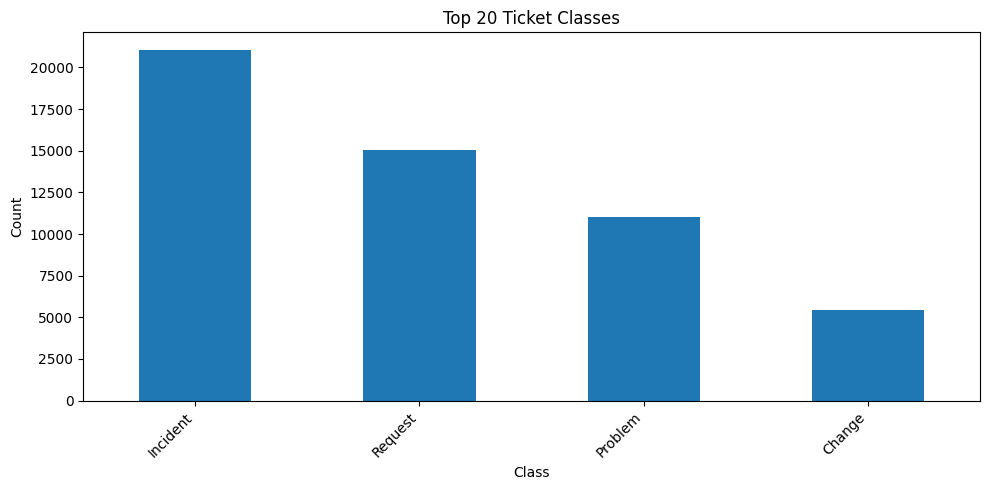

In [10]:
# ============================================================
# Class distribution
# ============================================================

class_counts = work_df["label"].value_counts()

display(class_counts.to_frame("count"))

plt.figure(figsize=(10, 5))
class_counts.head(20).plot(kind="bar")
plt.title("Top 20 Ticket Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

,text_length,word_count
count,52586.000000,52586.000000
mean,458.805481,64.038775
std,271.922687,39.251732
min,13.000000,1.000000
25%,260.000000,35.000000
50%,429.000000,60.000000
75%,604.000000,86.000000
max,2911.000000,394.000000


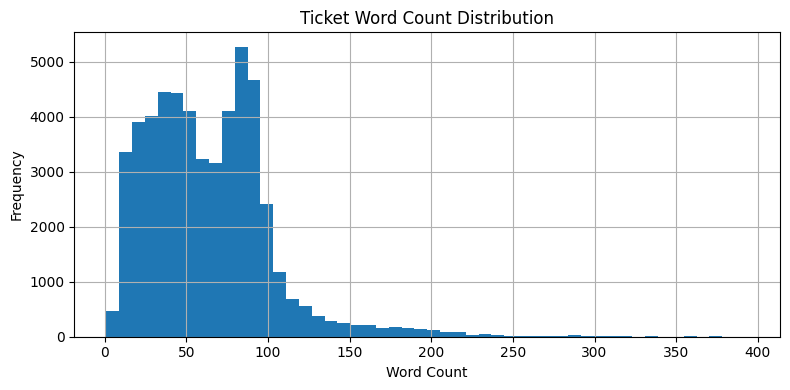

In [11]:
# ============================================================
# Text length analysis
# ============================================================

work_df["text_length"] = work_df["ticket_text"].str.len()
work_df["word_count"] = work_df["ticket_text"].str.split().str.len()

display(work_df[["text_length", "word_count"]].describe())

plt.figure(figsize=(8, 4))
work_df["word_count"].clip(upper=500).hist(bins=50)
plt.title("Ticket Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# Train/test split
# ============================================================

X = work_df["ticket_text"]
y = work_df["label"]

class_counts = y.value_counts()
can_stratify = class_counts.min() >= 2

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y if can_stratify else None
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Stratified split:", can_stratify)

Train size: 42068
Test size: 10518
Stratified split: True


In [13]:
# ============================================================
# TF-IDF + Logistic Regression baseline
# ============================================================

baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        max_features=50000
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

start_time = time.time()
baseline_model.fit(X_train, y_train)
train_time = time.time() - start_time

start_time = time.time()
y_pred = baseline_model.predict(X_test)
inference_time = time.time() - start_time

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("Baseline TF-IDF + Logistic Regression")
print("Accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))
print("Training time:", round(train_time, 2), "seconds")
print("Inference time:", round(inference_time, 4), "seconds")
print("Avg inference latency:", round((inference_time / len(X_test)) * 1000, 4), "ms/sample")

Baseline TF-IDF + Logistic Regression
Accuracy: 0.8286
Macro F1: 0.8402
Weighted F1: 0.8308
Training time: 18.74 seconds
Inference time: 0.8757 seconds
Avg inference latency: 0.0833 ms/sample


In [14]:
# ============================================================
# Per-class metrics
# ============================================================

report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose()

display(report_df)

print(classification_report(y_test, y_pred, zero_division=0))

,precision,recall,f1-score,support
Change,0.924866,0.950368,0.937443,1088.00000
Incident,0.841107,0.758015,0.797402,4211.00000
Problem,0.616095,0.723982,0.665696,2210.00000
Request,0.960439,0.960120,0.960279,3009.00000
accuracy,0.828580,0.828580,0.828580,0.82858
macro avg,0.835627,0.848121,0.840205,10518.00000
weighted avg,0.836631,0.828580,0.830811,10518.00000


              precision    recall  f1-score   support

      Change       0.92      0.95      0.94      1088
    Incident       0.84      0.76      0.80      4211
     Problem       0.62      0.72      0.67      2210
     Request       0.96      0.96      0.96      3009

    accuracy                           0.83     10518
   macro avg       0.84      0.85      0.84     10518
weighted avg       0.84      0.83      0.83     10518



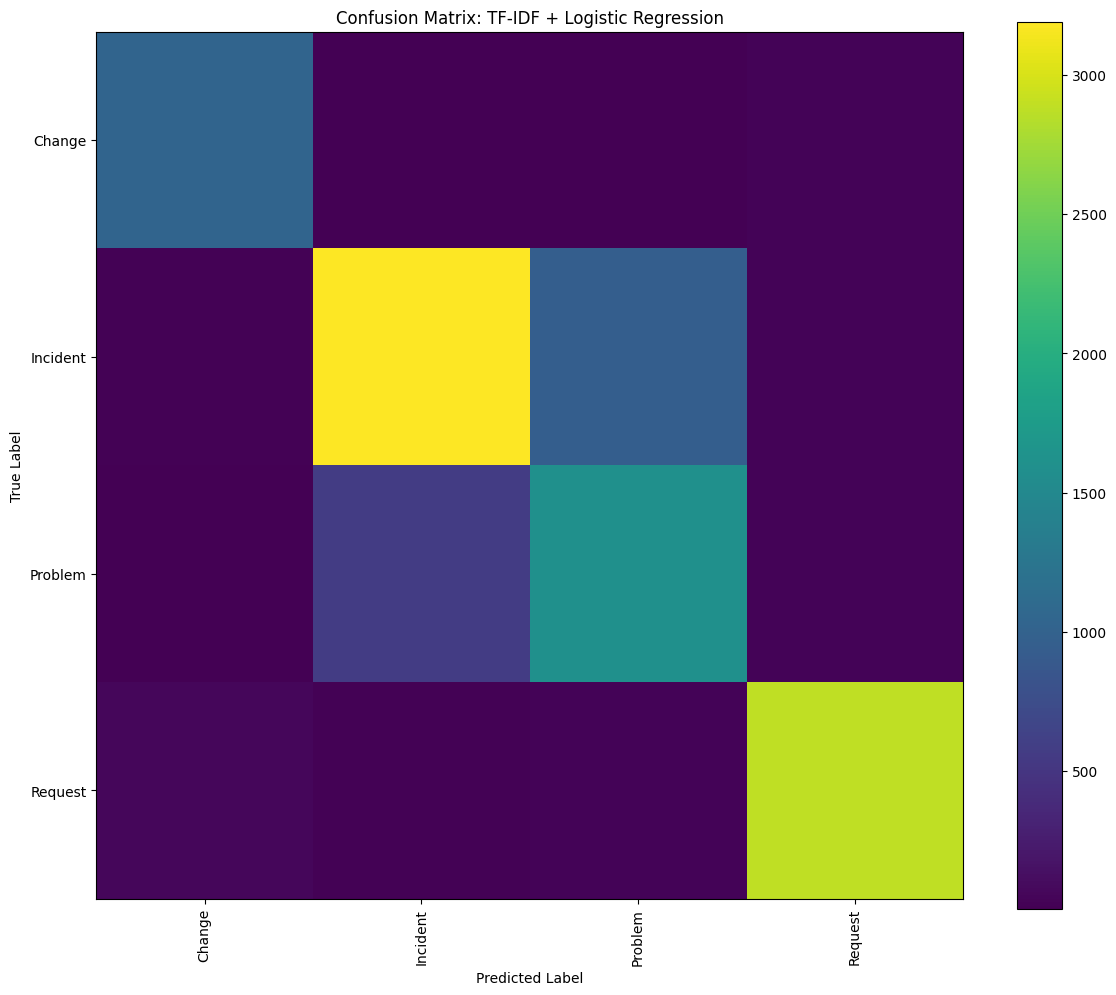

In [15]:
# ============================================================
# Confusion matrix
# ============================================================

labels_sorted = sorted(y_test.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix: TF-IDF + Logistic Regression")
plt.colorbar()

tick_marks = np.arange(len(labels_sorted))
plt.xticks(tick_marks, labels_sorted, rotation=90)
plt.yticks(tick_marks, labels_sorted)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# Error analysis: misclassified examples
# ============================================================

error_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "predicted_label": y_pred
})

error_df["is_correct"] = error_df["true_label"] == error_df["predicted_label"]

misclassified_df = error_df[~error_df["is_correct"]].copy()

print("Total misclassified:", len(misclassified_df))
display(misclassified_df.head(20))

Total misclassified: 1803


,text,true_label,predicted_label,is_correct
4,Support Request for Network Protection Issue R...,Problem,Incident,False
6,Unforeseen Charges in My Subscription Plan Hel...,Incident,Problem,False
15,Found Billing Discrepancies for Various Servic...,Incident,Problem,False
18,Problem with Project Synchronization Not Worki...,Incident,Problem,False
28,Incident of Data Breach Resulted from Encrypti...,Incident,Problem,False
49,Bericht über Unterbrechungen beim Zugriff auf ...,Problem,Incident,False
50,Urgent Reporting of Severe Data Breach Event d...,Incident,Problem,False
57,Missing ticket notifications impacting Jira fe...,Problem,Incident,False
61,Need Assistance with Data Analysis Software Bu...,Problem,Incident,False
67,Hilfe bei Datenverletzungen Patientenmedizinis...,Incident,Problem,False


In [17]:
# ============================================================
# Most confused label pairs
# ============================================================

confusion_pairs = (
    misclassified_df
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(confusion_pairs.head(20))

,true_label,predicted_label,count
4,Incident,Problem,958
7,Problem,Incident,568
9,Request,Change,59
5,Incident,Request,42
2,Change,Request,41
8,Problem,Request,36
11,Request,Problem,34
10,Request,Incident,27
3,Incident,Change,19
0,Change,Incident,8


In [18]:
# ============================================================
# Save baseline model
# ============================================================

baseline_model_path = os.path.join(ARTIFACT_DIR, "tfidf_logreg_ticket_classifier.pkl")

with open(baseline_model_path, "wb") as f:
    pickle.dump(baseline_model, f)

print("Saved baseline model to:", baseline_model_path)

Saved baseline model to: artifacts\tfidf_logreg_ticket_classifier.pkl


In [19]:
# ============================================================
# Optional: Install dependencies if needed
# Run this cell only if transformers/datasets are not installed
# ============================================================

!pip install transformers datasets accelerate torch -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
# ============================================================
# Optional CPU-only DistilBERT setup
# ============================================================

RUN_DISTILBERT = False   # Change to True when you want to run it
DISTILBERT_SAMPLE_SIZE = 2000
DISTILBERT_EPOCHS = 1
DISTILBERT_MAX_LENGTH = 128

In [21]:
# ============================================================
# Optional CPU-only DistilBERT fine-tuning
# ============================================================

if RUN_DISTILBERT:
    import torch
    from datasets import Dataset
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        TrainingArguments,
        Trainer
    )

    device = torch.device("cpu")
    print("Using device:", device)

    # Sample for CPU practicality
    bert_df = work_df[["ticket_text", "label"]].copy()

    if len(bert_df) > DISTILBERT_SAMPLE_SIZE:
        bert_df = bert_df.sample(DISTILBERT_SAMPLE_SIZE, random_state=RANDOM_STATE)

    label_list = sorted(bert_df["label"].unique())
    label2id = {label: i for i, label in enumerate(label_list)}
    id2label = {i: label for label, i in label2id.items()}

    bert_df["label_id"] = bert_df["label"].map(label2id)

    train_df, test_df = train_test_split(
        bert_df,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=bert_df["label_id"] if bert_df["label_id"].value_counts().min() >= 2 else None
    )

    model_name = "distilbert-base-uncased"

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_batch(batch):
        return tokenizer(
            batch["ticket_text"],
            padding="max_length",
            truncation=True,
            max_length=DISTILBERT_MAX_LENGTH
        )

    train_dataset = Dataset.from_pandas(train_df[["ticket_text", "label_id"]])
    test_dataset = Dataset.from_pandas(test_df[["ticket_text", "label_id"]])

    train_dataset = train_dataset.map(tokenize_batch, batched=True)
    test_dataset = test_dataset.map(tokenize_batch, batched=True)

    train_dataset = train_dataset.rename_column("label_id", "labels")
    test_dataset = test_dataset.rename_column("label_id", "labels")

    train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
    test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(label_list),
        id2label=id2label,
        label2id=label2id
    )

    model.to(device)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)

        return {
            "accuracy": accuracy_score(labels, preds),
            "macro_f1": f1_score(labels, preds, average="macro"),
            "weighted_f1": f1_score(labels, preds, average="weighted")
        }

    training_args = TrainingArguments(
        output_dir=os.path.join(ARTIFACT_DIR, "distilbert_ticket_classifier"),
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=DISTILBERT_EPOCHS,
        weight_decay=0.01,
        logging_steps=50,
        no_cuda=True,
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics
    )

    trainer.train()

    bert_metrics = trainer.evaluate()
    print(bert_metrics)

    model.save_pretrained(os.path.join(ARTIFACT_DIR, "distilbert_ticket_classifier_final"))
    tokenizer.save_pretrained(os.path.join(ARTIFACT_DIR, "distilbert_ticket_classifier_final"))

else:
    print("Skipping DistilBERT fine-tuning. Set RUN_DISTILBERT = True to enable CPU training.")

Skipping DistilBERT fine-tuning. Set RUN_DISTILBERT = True to enable CPU training.


In [22]:
# ============================================================
# Build knowledge base
# ============================================================

kb_df = work_df.copy()

def build_document(row):
    parts = []

    parts.append("Ticket:")
    parts.append(row["ticket_text"])

    if row["support_answer"]:
        parts.append("\nSupport Answer:")
        parts.append(row["support_answer"])

    parts.append("\nCategory:")
    parts.append(str(row["label"]))

    return "\n".join(parts)

kb_df["document"] = kb_df.apply(build_document, axis=1)

kb_df = kb_df.reset_index(drop=True)
kb_df["doc_id"] = kb_df.index.astype(str)

print("Knowledge base size:", len(kb_df))
display(kb_df[["doc_id", "label", "document"]].head())

Knowledge base size: 52586


,doc_id,label,document
0,0,Incident,Ticket:\nWesentlicher Sicherheitsvorfall Sehr ...
1,1,Incident,Ticket:\nAccount Disruption Dear Customer Supp...
2,2,Request,Ticket:\nQuery About Smart Home System Integra...
3,3,Request,Ticket:\nInquiry Regarding Invoice Details Dea...
4,4,Problem,Ticket:\nQuestion About Marketing Agency Softw...


In [23]:
# ============================================================
# Install if needed
# ============================================================

!pip install sentence-transformers -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
# ============================================================
# Embedding backend selection
# Safe CPU-only version
# ============================================================

USE_SENTENCE_TRANSFORMERS = False

print("Using TF-IDF retrieval backend.")
print("Reason: sentence-transformers/PyTorch is unavailable or disabled.")

Using TF-IDF retrieval backend.
Reason: sentence-transformers/PyTorch is unavailable or disabled.


In [26]:
# ============================================================
# Build embedding index
# ============================================================

if USE_SENTENCE_TRANSFORMERS:
    embed_model_name = "sentence-transformers/all-MiniLM-L6-v2"
    embedder = SentenceTransformer(embed_model_name, device="cpu")

    documents = kb_df["document"].tolist()

    start_time = time.time()
    doc_embeddings = embedder.encode(
        documents,
        batch_size=32,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    embedding_time = time.time() - start_time

    print("Embedding shape:", doc_embeddings.shape)
    print("Embedding time:", round(embedding_time, 2), "seconds")

    nn_index = NearestNeighbors(
        n_neighbors=TOP_K,
        metric="cosine",
        algorithm="brute"
    )

    nn_index.fit(doc_embeddings)

else:
    print("Skipping sentence-transformer embeddings.")

Skipping sentence-transformer embeddings.


In [27]:
# ============================================================
# TF-IDF retrieval fallback
# ============================================================

retrieval_tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=50000
)

tfidf_doc_matrix = retrieval_tfidf.fit_transform(kb_df["document"])

tfidf_nn_index = NearestNeighbors(
    n_neighbors=TOP_K,
    metric="cosine",
    algorithm="brute"
)

tfidf_nn_index.fit(tfidf_doc_matrix)

print("TF-IDF retrieval matrix shape:", tfidf_doc_matrix.shape)

TF-IDF retrieval matrix shape: (52586, 50000)


In [28]:
# ============================================================
# Search function
# ============================================================

def semantic_search(query, top_k=5, use_embeddings=True):
    query = clean_text(query)

    if use_embeddings and USE_SENTENCE_TRANSFORMERS:
        query_embedding = embedder.encode(
            [query],
            normalize_embeddings=True
        )

        distances, indices = nn_index.kneighbors(
            query_embedding,
            n_neighbors=top_k
        )

        results = []
        for rank, idx in enumerate(indices[0], start=1):
            distance = distances[0][rank - 1]
            score = 1 - distance

            row = kb_df.iloc[idx]

            results.append({
                "rank": rank,
                "doc_id": row["doc_id"],
                "score": float(score),
                "label": row["label"],
                "ticket_text": row["ticket_text"],
                "support_answer": row["support_answer"],
                "document": row["document"]
            })

        return pd.DataFrame(results)

    else:
        query_vector = retrieval_tfidf.transform([query])

        distances, indices = tfidf_nn_index.kneighbors(
            query_vector,
            n_neighbors=top_k
        )

        results = []
        for rank, idx in enumerate(indices[0], start=1):
            distance = distances[0][rank - 1]
            score = 1 - distance

            row = kb_df.iloc[idx]

            results.append({
                "rank": rank,
                "doc_id": row["doc_id"],
                "score": float(score),
                "label": row["label"],
                "ticket_text": row["ticket_text"],
                "support_answer": row["support_answer"],
                "document": row["document"]
            })

        return pd.DataFrame(results)

In [29]:
# ============================================================
# Qualitative semantic search example
# ============================================================

sample_query = X_test.iloc[0]

print("Query:")
print(sample_query)

search_results = semantic_search(sample_query, top_k=5, use_embeddings=True)

display(search_results[["rank", "score", "label", "ticket_text", "support_answer"]])

Query:
Issues with Investment Forecast Accuracy I am contacting you to address the inaccuracies in the investment forecasts. There appears to be a problem due to poor data quality. After reviewing the data sources and rerunning the models, the issue still exists. I would greatly appreciate your help in addressing this to enhance the precision of the forecasts.


,rank,score,label,ticket_text,support_answer
0,1,0.746232,Problem,Issues with Investment Forecast Accuracy I am ...,"Dear <name>, thank you for bringing the issues..."
1,2,0.534140,Problem,Investment Forecasts Have Inaccuracies I am co...,"Dear <name>, thank you for bringing the inaccu..."
2,3,0.477357,Problem,Accuracy Issues with Investment Forecasts I ha...,"Dear <name>, we appreciate you bringing this i..."
3,4,0.357712,Problem,Discrepancies in Investment Forecasts Detected...,We will reassess and modernize our models to o...
4,5,0.353303,Problem,Detected Inaccuracies in Investment Forecasts ...,We will reassess and modernize our models to e...


In [30]:
# ============================================================
# Retrieval evaluation
# ============================================================

def evaluate_retrieval(eval_df, top_k=5, sample_size=500, use_embeddings=True):
    if len(eval_df) > sample_size:
        eval_sample = eval_df.sample(sample_size, random_state=RANDOM_STATE)
    else:
        eval_sample = eval_df.copy()

    recall_hits = []
    reciprocal_ranks = []

    for _, row in eval_sample.iterrows():
        query = row["ticket_text"]
        true_label = row["label"]

        results = semantic_search(
            query,
            top_k=top_k + 1,
            use_embeddings=use_embeddings
        )

        # Remove exact same text if it appears as nearest neighbor
        results = results[results["ticket_text"] != query].head(top_k)

        retrieved_labels = results["label"].tolist()

        hit = int(true_label in retrieved_labels)
        recall_hits.append(hit)

        rr = 0
        for rank, label in enumerate(retrieved_labels, start=1):
            if label == true_label:
                rr = 1 / rank
                break

        reciprocal_ranks.append(rr)

    metrics = {
        f"Recall@{top_k}": np.mean(recall_hits),
        "MRR": np.mean(reciprocal_ranks),
        "evaluated_queries": len(eval_sample)
    }

    return metrics


retrieval_metrics = evaluate_retrieval(
    work_df,
    top_k=TOP_K,
    sample_size=500,
    use_embeddings=True
)

retrieval_metrics

{'Recall@5': 0.966, 'MRR': 0.9098333333333333, 'evaluated_queries': 500}

In [31]:
# ============================================================
# RAG-style answer generation
# CPU-only, retrieval-grounded, no external API
# ============================================================

def classify_ticket(query):
    prediction = baseline_model.predict([query])[0]

    if hasattr(baseline_model.named_steps["clf"], "predict_proba"):
        probabilities = baseline_model.predict_proba([query])[0]
        confidence = probabilities.max()
    else:
        confidence = None

    return prediction, confidence


def generate_grounded_answer(query, top_k=5, min_score=0.25):
    query = clean_text(query)

    predicted_label, classification_confidence = classify_ticket(query)

    retrieved = semantic_search(
        query,
        top_k=top_k,
        use_embeddings=True
    )

    strong_results = retrieved[retrieved["score"] >= min_score].copy()

    if len(strong_results) == 0:
        answer = (
            "I could not find a sufficiently similar resolved support case. "
            "This query should be escalated to a human support agent or routed "
            "to the predicted support queue for manual review."
        )

        grounding_note = "Low retrieval confidence. No answer generated from historical responses."

    else:
        answer_candidates = (
            strong_results["support_answer"]
            .dropna()
            .astype(str)
            .map(clean_text)
        )

        answer_candidates = answer_candidates[answer_candidates.str.len() > 20]

        if len(answer_candidates) > 0:
            answer = answer_candidates.iloc[0]
            grounding_note = (
                "Answer is grounded in the highest-ranked historical support response. "
                "It should be reviewed before customer-facing use."
            )
        else:
            top_doc = strong_results.iloc[0]["ticket_text"]
            answer = (
                "I found similar historical support tickets, but no clear agent response was available. "
                "The closest matching case describes: "
                + top_doc[:500]
            )
            grounding_note = (
                "Retrieved similar cases, but response field was missing or too short."
            )

    result = {
        "query": query,
        "predicted_label": predicted_label,
        "classification_confidence": classification_confidence,
        "answer": answer,
        "grounding_note": grounding_note,
        "retrieved_documents": retrieved
    }

    return result

In [32]:
# ============================================================
# Demo query
# ============================================================

demo_query = """
I cannot access my account after resetting my password.
The login page keeps saying my credentials are invalid.
"""

rag_result = generate_grounded_answer(
    demo_query,
    top_k=5,
    min_score=0.25
)

print("USER QUERY:")
print(rag_result["query"])

print("\nPREDICTED CATEGORY:")
print(rag_result["predicted_label"])

print("\nCLASSIFICATION CONFIDENCE:")
print(rag_result["classification_confidence"])

print("\nGROUNDED ANSWER:")
print(rag_result["answer"])

print("\nGROUNDING NOTE:")
print(rag_result["grounding_note"])

print("\nRETRIEVED DOCUMENTS:")
display(
    rag_result["retrieved_documents"][
        ["rank", "score", "label", "ticket_text", "support_answer"]
    ]
)

USER QUERY:
I cannot access my account after resetting my password. The login page keeps saying my credentials are invalid.

PREDICTED CATEGORY:
Incident

CLASSIFICATION CONFIDENCE:
0.583720744446141

GROUNDED ANSWER:
Thank you for reaching out to us regarding the issue with accessing your account's billing and payments. We are sorry to hear that you are experiencing these difficulties, especially after you have already tried resetting your password and clearing your browser cache. To assist you further, could you please provide us with your account number and a detailed description of the error message you are receiving when trying to access your account? This information will help us better understand the issue and work towards a resolution. If necessary, we may need to contact you directly.

GROUNDING NOTE:
Answer is grounded in the highest-ranked historical support response. It should be reviewed before customer-facing use.

RETRIEVED DOCUMENTS:


,rank,score,label,ticket_text,support_answer
0,1,0.343957,Problem,Problem with Account Access I am unable to acc...,Thank you for reaching out to us regarding the...
1,2,0.320599,Request,Client can't log in to Jira Software 8.20.,We're looking into your login issue. Please tr...
2,3,0.273955,Problem,Problem with Account Access I am unable to acc...,"<name>, thank you for reaching out to us regar..."
3,4,0.253403,Change,Request to Change Microsoft Office 365 Credent...,"Dear <name>, Thank you for contacting us. Plea..."
4,5,0.250395,Incident,Recurring Login Challenges with User Account T...,"To address the intermittent login issues, plea..."


In [33]:
# ============================================================
# Retrieval failure analysis
# ============================================================

def collect_retrieval_failures(eval_df, top_k=5, sample_size=200, use_embeddings=True):
    if len(eval_df) > sample_size:
        eval_sample = eval_df.sample(sample_size, random_state=RANDOM_STATE)
    else:
        eval_sample = eval_df.copy()

    failures = []

    for _, row in eval_sample.iterrows():
        query = row["ticket_text"]
        true_label = row["label"]

        results = semantic_search(
            query,
            top_k=top_k + 1,
            use_embeddings=use_embeddings
        )

        results = results[results["ticket_text"] != query].head(top_k)
        retrieved_labels = results["label"].tolist()

        if true_label not in retrieved_labels:
            failures.append({
                "query": query,
                "true_label": true_label,
                "top_retrieved_labels": retrieved_labels,
                "top_score": results["score"].iloc[0] if len(results) else None,
                "top_retrieved_text": results["ticket_text"].iloc[0] if len(results) else None
            })

    return pd.DataFrame(failures)


retrieval_failures_df = collect_retrieval_failures(
    work_df,
    top_k=TOP_K,
    sample_size=200,
    use_embeddings=True
)

print("Retrieval failures:", len(retrieval_failures_df))
display(retrieval_failures_df.head(20))

Retrieval failures: 6


,query,true_label,top_retrieved_labels,top_score,top_retrieved_text
0,Besoin d'assistance : problème de garantie Del...,Request,"[Problem, Incident, Problem, Problem, Incident]",0.588463,Urgent : Problème de surchauffe avec le Dell X...
1,"Data Access Problem Customer Support, reportin...",Incident,"[Problem, Problem, Problem, Problem, Problem]",0.266582,Urgent: Critical Data Access Problem for Healt...
2,Discrepance de facturation Cher service client...,Request,"[Problem, Problem, Incident, Incident, Change]",0.613359,Problème de double facturation Bonjour Service...
3,Habe Probleme mit OBS Studio 27 bei macOS Mont...,Problem,"[Incident, Incident, Incident, Incident, Incid...",0.360546,Probleme mit der Integration von OBS Studio Es...
4,Support for Latest Project Schedule Updates on...,Problem,"[Incident, Incident, Incident, Incident]",0.353581,Project Schedule View Not Functional The proje...
5,Problem with Smart Robot Mop Device The Smart ...,Incident,"[Request, Problem, Problem, Problem, Request]",0.464339,Detaillierte Rechnungsdaten zu Smart-Robot-Mop...


In [34]:
# ============================================================
# RAG hallucination risk checks
# ============================================================

def assess_rag_risk(rag_result, score_threshold=0.35, confidence_threshold=0.50):
    risks = []

    retrieved = rag_result["retrieved_documents"]

    top_score = retrieved["score"].iloc[0] if len(retrieved) > 0 else 0
    classification_confidence = rag_result["classification_confidence"]

    if top_score < score_threshold:
        risks.append("Low retrieval similarity score")

    if classification_confidence is not None and classification_confidence < confidence_threshold:
        risks.append("Low classification confidence")

    if "could not find" in rag_result["answer"].lower():
        risks.append("No grounded answer available")

    if len(risks) == 0:
        risk_level = "Low"
    elif len(risks) == 1:
        risk_level = "Medium"
    else:
        risk_level = "High"

    return {
        "risk_level": risk_level,
        "risks": risks,
        "top_retrieval_score": top_score,
        "classification_confidence": classification_confidence
    }


risk_report = assess_rag_risk(rag_result)

risk_report

{'risk_level': 'Medium',
 'risks': ['Low retrieval similarity score'],
 'top_retrieval_score': 0.34395663710529567,
 'classification_confidence': 0.583720744446141}

In [35]:
# ============================================================
# Experiment tracking table
# ============================================================

experiment_rows = []

experiment_rows.append({
    "experiment_name": "tfidf_logreg_baseline",
    "task": "ticket_classification",
    "model": "TF-IDF + Logistic Regression",
    "accuracy": accuracy,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
    "train_time_sec": train_time,
    "inference_time_sec": inference_time,
    "avg_latency_ms_per_sample": (inference_time / len(X_test)) * 1000,
    "notes": "CPU-only baseline with balanced class weights"
})

experiment_rows.append({
    "experiment_name": "semantic_retrieval",
    "task": "semantic_search",
    "model": "SentenceTransformer all-MiniLM-L6-v2 + NearestNeighbors"
             if USE_SENTENCE_TRANSFORMERS else
             "TF-IDF + NearestNeighbors",
    "accuracy": None,
    "macro_f1": None,
    "weighted_f1": None,
    "train_time_sec": None,
    "inference_time_sec": None,
    "avg_latency_ms_per_sample": None,
    "notes": json.dumps(retrieval_metrics)
})

experiment_df = pd.DataFrame(experiment_rows)

display(experiment_df)

experiment_path = os.path.join(ARTIFACT_DIR, "experiment_results.csv")
experiment_df.to_csv(experiment_path, index=False)

print("Saved experiment table to:", experiment_path)

,experiment_name,task,model,accuracy,macro_f1,weighted_f1,train_time_sec,inference_time_sec,avg_latency_ms_per_sample,notes
0,tfidf_logreg_baseline,ticket_classification,TF-IDF + Logistic Regression,0.82858,0.840205,0.830811,18.739514,0.875676,0.083255,CPU-only baseline with balanced class weights
1,semantic_retrieval,semantic_search,TF-IDF + NearestNeighbors,NaN,NaN,NaN,NaN,NaN,NaN,"{""Recall@5"": 0.966, ""MRR"": 0.9098333333333333,..."


Saved experiment table to: artifacts\experiment_results.csv


In [36]:
# ============================================================
# Save retrieval artifacts
# ============================================================

kb_path = os.path.join(ARTIFACT_DIR, "support_knowledge_base.csv")
kb_df.to_csv(kb_path, index=False)

tfidf_retrieval_path = os.path.join(ARTIFACT_DIR, "tfidf_retrieval_vectorizer.pkl")
tfidf_index_path = os.path.join(ARTIFACT_DIR, "tfidf_nearest_neighbors.pkl")

with open(tfidf_retrieval_path, "wb") as f:
    pickle.dump(retrieval_tfidf, f)

with open(tfidf_index_path, "wb") as f:
    pickle.dump(tfidf_nn_index, f)

print("Saved knowledge base:", kb_path)
print("Saved TF-IDF retrieval vectorizer:", tfidf_retrieval_path)
print("Saved TF-IDF nearest-neighbor index:", tfidf_index_path)

if USE_SENTENCE_TRANSFORMERS:
    embedding_path = os.path.join(ARTIFACT_DIR, "document_embeddings.npy")
    np.save(embedding_path, doc_embeddings)
    print("Saved document embeddings:", embedding_path)

Saved knowledge base: artifacts\support_knowledge_base.csv
Saved TF-IDF retrieval vectorizer: artifacts\tfidf_retrieval_vectorizer.pkl
Saved TF-IDF nearest-neighbor index: artifacts\tfidf_nearest_neighbors.pkl


In [37]:
# ============================================================
# End-to-end inference function
# ============================================================

def support_intelligence_pipeline(user_query, top_k=5):
    start = time.time()

    predicted_label, classification_confidence = classify_ticket(user_query)

    retrieved_docs = semantic_search(
        user_query,
        top_k=top_k,
        use_embeddings=True
    )

    rag_output = generate_grounded_answer(
        user_query,
        top_k=top_k
    )

    risk = assess_rag_risk(rag_output)

    total_latency = time.time() - start

    output = {
        "query": user_query,
        "predicted_label": predicted_label,
        "classification_confidence": classification_confidence,
        "answer": rag_output["answer"],
        "grounding_note": rag_output["grounding_note"],
        "risk_report": risk,
        "retrieved_documents": retrieved_docs,
        "latency_seconds": total_latency
    }

    return output

In [38]:
# ============================================================
# Final demo
# ============================================================

user_query = """
My order was charged twice and I need a refund.
Can someone help me reverse the duplicate payment?
"""

output = support_intelligence_pipeline(user_query, top_k=5)

print("QUERY:")
print(output["query"])

print("\nPREDICTED LABEL:")
print(output["predicted_label"])

print("\nCLASSIFICATION CONFIDENCE:")
print(output["classification_confidence"])

print("\nANSWER:")
print(output["answer"])

print("\nGROUNDING NOTE:")
print(output["grounding_note"])

print("\nRISK REPORT:")
print(output["risk_report"])

print("\nLATENCY SECONDS:")
print(output["latency_seconds"])

print("\nRETRIEVED DOCUMENTS:")
display(output["retrieved_documents"][["rank", "score", "label", "ticket_text", "support_answer"]])

QUERY:

My order was charged twice and I need a refund.
Can someone help me reverse the duplicate payment?


PREDICTED LABEL:
Problem

CLASSIFICATION CONFIDENCE:
0.5766767920267146

ANSWER:
<name>, I'm sorry to hear that you were charged twice for the monthly subscription. We will investigate the matter and work on refunding the extra charge as soon as possible. To assist with the resolution, could you please provide your account number and the dates of the double charges? If you need to discuss this further, you can contact us at <tel_num>. Please allow 24-48 hours for us to look into the issue, and we will update you regarding the refund and any additional steps needed to prevent this in the future.

GROUNDING NOTE:
Answer is grounded in the highest-ranked historical support response. It should be reviewed before customer-facing use.

RISK REPORT:
{'risk_level': 'Low', 'risks': [], 'top_retrieval_score': 0.42510340641974187, 'classification_confidence': 0.5766767920267146}

LATENCY S

,rank,score,label,ticket_text,support_answer
0,1,0.425103,Problem,Problem with Monthly Subscription Being Charge...,"<name>, I'm sorry to hear that you were charge..."
1,2,0.425103,Problem,Problem with Monthly Subscription Being Charge...,"<name>, I'm sorry to hear that you were charge..."
2,3,0.413761,Problem,Concern Regarding Project Management Subscript...,"<name>, we appreciate you bringing this issue ..."
3,4,0.375812,Incident,I was charged twice for the subscription perio...,We will investigate the duplicate charge issue...
4,5,0.373934,Problem,Issues with Project Management Subscription ch...,"Dear <name>, thank you for bringing this to ou..."


In [39]:
# ============================================================
# Generate notebook summary
# ============================================================

summary = {
    "dataset_rows": len(work_df),
    "num_classes": work_df["label"].nunique(),
    "selected_text_columns": TEXT_COLUMNS,
    "selected_label_column": LABEL_COLUMN,
    "selected_answer_column": ANSWER_COLUMN,
    "classification_accuracy": accuracy,
    "classification_macro_f1": macro_f1,
    "classification_weighted_f1": weighted_f1,
    "retrieval_metrics": retrieval_metrics,
    "top_confused_pairs": confusion_pairs.head(10).to_dict(orient="records"),
    "num_misclassified_examples": len(misclassified_df),
    "num_retrieval_failures_sample": len(retrieval_failures_df)
}

summary_path = os.path.join(ARTIFACT_DIR, "project_summary.json")

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4)

summary

{'dataset_rows': 52586,
 'num_classes': 4,
 'selected_text_columns': ['subject', 'body'],
 'selected_label_column': 'type',
 'selected_answer_column': 'answer',
 'classification_accuracy': 0.8285795778665146,
 'classification_macro_f1': 0.8402050885014883,
 'classification_weighted_f1': 0.8308106052391806,
 'retrieval_metrics': {'Recall@5': 0.966,
  'MRR': 0.9098333333333333,
  'evaluated_queries': 500},
 'top_confused_pairs': [{'true_label': 'Incident',
   'predicted_label': 'Problem',
   'count': 958},
  {'true_label': 'Problem', 'predicted_label': 'Incident', 'count': 568},
  {'true_label': 'Request', 'predicted_label': 'Change', 'count': 59},
  {'true_label': 'Incident', 'predicted_label': 'Request', 'count': 42},
  {'true_label': 'Change', 'predicted_label': 'Request', 'count': 41},
  {'true_label': 'Problem', 'predicted_label': 'Request', 'count': 36},
  {'true_label': 'Request', 'predicted_label': 'Problem', 'count': 34},
  {'true_label': 'Request', 'predicted_label': 'Incident'

In [40]:
# ============================================================
# Portfolio-ready project summary
# ============================================================

project_description = f"""
# Customer Support Intelligence System

This project implements an end-to-end NLP support intelligence system in a Jupyter notebook.

## Dataset

The system uses a real-world customer IT support ticket dataset loaded from a local dataset directory.
The notebook automatically detects dataset files, text fields, label fields, and support answer fields where available.

## Task 1: Ticket Classification

A TF-IDF + Logistic Regression baseline was trained to classify incoming support tickets.

Metrics:

- Accuracy: {accuracy:.4f}
- Macro F1: {macro_f1:.4f}
- Weighted F1: {weighted_f1:.4f}

The notebook includes per-class precision, recall, F1-score, a confusion matrix, and misclassification analysis.

## Task 2: Semantic Search

A semantic retrieval system was built over historical tickets and support answers.

Retrieval metrics:

{retrieval_metrics}

The system retrieves similar historical cases for new support queries.

## Task 3: RAG-Style Answering

The notebook implements retrieval-grounded answer generation.
For each user query, the system:

1. Classifies the ticket.
2. Retrieves similar historical support cases.
3. Generates a grounded response from retrieved support answers.
4. Reports confidence and hallucination risk notes.

## Task 4: Error Analysis

The project includes:

- Misclassified examples
- Most confused class pairs
- Class imbalance analysis
- Retrieval failure analysis
- Hallucination risk checks
- Latency measurement
- Saved artifacts
- Reproducible inference pipeline

## Deployment Notes

This notebook is CPU-only and saves reusable artifacts, including the classifier, retrieval index, embeddings, experiment table, and knowledge base.
"""

print(project_description)


# Customer Support Intelligence System

This project implements an end-to-end NLP support intelligence system in a Jupyter notebook.

## Dataset

The system uses a real-world customer IT support ticket dataset loaded from a local dataset directory.
The notebook automatically detects dataset files, text fields, label fields, and support answer fields where available.

## Task 1: Ticket Classification

A TF-IDF + Logistic Regression baseline was trained to classify incoming support tickets.

Metrics:

- Accuracy: 0.8286
- Macro F1: 0.8402
- Weighted F1: 0.8308

The notebook includes per-class precision, recall, F1-score, a confusion matrix, and misclassification analysis.

## Task 2: Semantic Search

A semantic retrieval system was built over historical tickets and support answers.

Retrieval metrics:

{'Recall@5': 0.966, 'MRR': 0.9098333333333333, 'evaluated_queries': 500}

The system retrieves similar historical cases for new support queries.

## Task 3: RAG-Style Answering

The noteb

In [41]:
# ============================================================
# Resume bullet
# ============================================================

resume_bullet = f"""
Built an end-to-end CPU-only NLP customer support intelligence system in Jupyter, combining TF-IDF + Logistic Regression ticket classification, semantic retrieval, and RAG-style grounded answering; achieved {macro_f1:.2f} macro F1 and {weighted_f1:.2f} weighted F1 on ticket classification, evaluated retrieval with Recall@{TOP_K} and MRR, and added production-oriented error analysis, latency measurement, saved artifacts, and hallucination risk checks.
"""

print(resume_bullet)


Built an end-to-end CPU-only NLP customer support intelligence system in Jupyter, combining TF-IDF + Logistic Regression ticket classification, semantic retrieval, and RAG-style grounded answering; achieved 0.84 macro F1 and 0.83 weighted F1 on ticket classification, evaluated retrieval with Recall@5 and MRR, and added production-oriented error analysis, latency measurement, saved artifacts, and hallucination risk checks.



In [42]:
# ============================================================
# Visualization utilities
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_barh(series, title, xlabel, ylabel, top_n=20):
    data = series.head(top_n).sort_values()

    plt.figure(figsize=(10, max(5, len(data) * 0.35)))
    data.plot(kind="barh")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

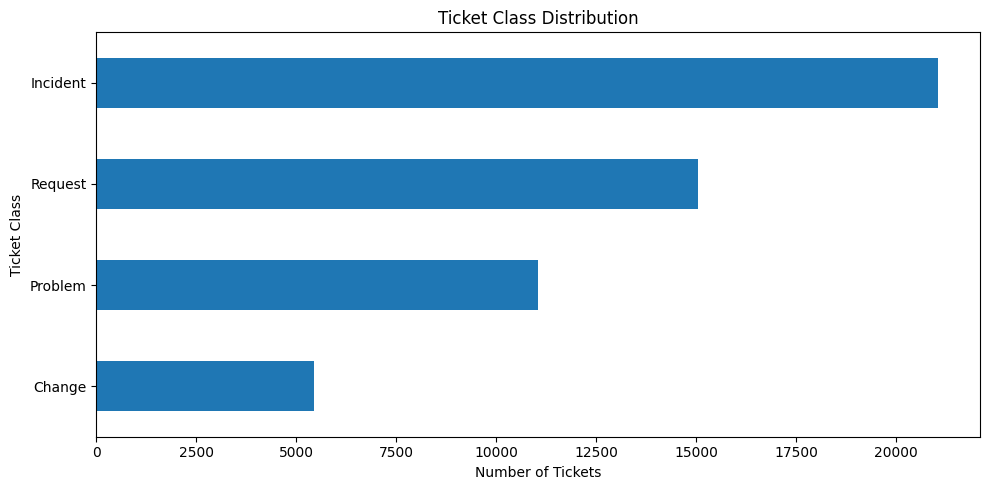

Number of classes: 4
Largest class size: 21052
Smallest class size: 5439
Class imbalance ratio: 3.87


In [43]:
# ============================================================
# Class distribution visualization
# ============================================================

class_counts = work_df["label"].value_counts()

plot_barh(
    class_counts,
    title="Ticket Class Distribution",
    xlabel="Number of Tickets",
    ylabel="Ticket Class",
    top_n=20
)

imbalance_ratio = class_counts.max() / class_counts.min()

print("Number of classes:", work_df["label"].nunique())
print("Largest class size:", class_counts.max())
print("Smallest class size:", class_counts.min())
print("Class imbalance ratio:", round(imbalance_ratio, 2))

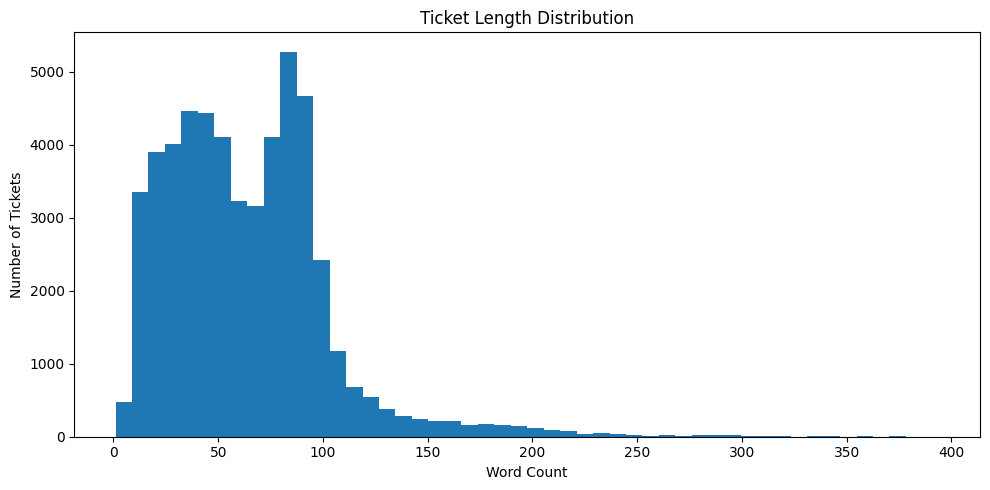

count    52586.000000
mean        64.038775
std         39.251732
min          1.000000
25%         35.000000
50%         60.000000
75%         86.000000
max        394.000000
Name: word_count, dtype: float64


In [44]:
# ============================================================
# Ticket length visualization
# ============================================================

work_df["word_count"] = work_df["ticket_text"].str.split().str.len()

plt.figure(figsize=(10, 5))
plt.hist(work_df["word_count"].clip(upper=500), bins=50)
plt.title("Ticket Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

print(work_df["word_count"].describe())

In [45]:
accuracy
macro_f1
weighted_f1

0.8308106052391806

,metric,score
0,Accuracy,0.828580
1,Macro F1,0.840205
2,Weighted F1,0.830811


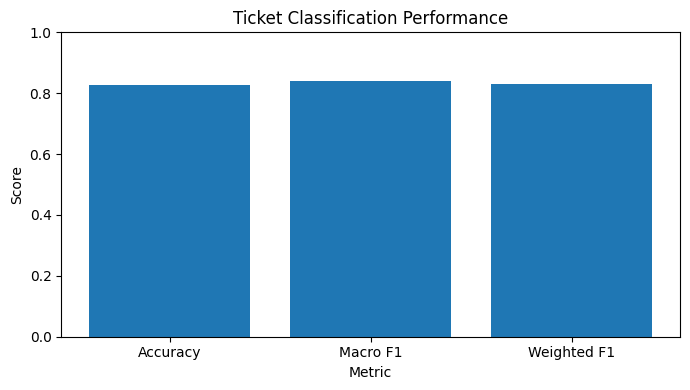

In [46]:
# ============================================================
# Classification metrics visualization
# ============================================================

metrics_df = pd.DataFrame({
    "metric": ["Accuracy", "Macro F1", "Weighted F1"],
    "score": [accuracy, macro_f1, weighted_f1]
})

display(metrics_df)

plt.figure(figsize=(7, 4))
plt.bar(metrics_df["metric"], metrics_df["score"])
plt.ylim(0, 1)
plt.title("Ticket Classification Performance")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

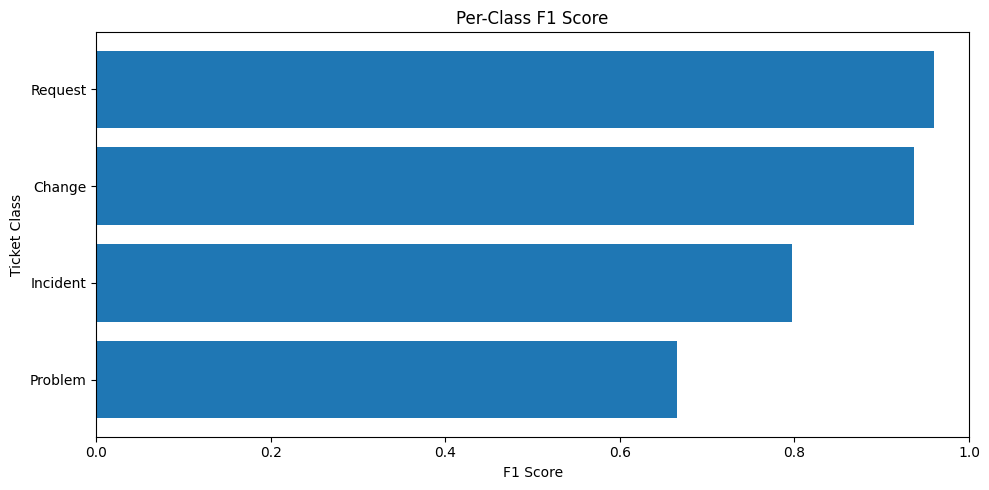

,precision,recall,f1-score,support
Problem,0.616095,0.723982,0.665696,2210.0
Incident,0.841107,0.758015,0.797402,4211.0
Change,0.924866,0.950368,0.937443,1088.0
Request,0.960439,0.960120,0.960279,3009.0


In [47]:
# ============================================================
# Per-class F1 score visualization
# ============================================================

per_class_report = report_df.copy()

# Keep only real class rows
per_class_report = per_class_report[
    ~per_class_report.index.isin(["accuracy", "macro avg", "weighted avg"])
].copy()

per_class_report = per_class_report.sort_values("f1-score", ascending=True)

plt.figure(figsize=(10, max(5, len(per_class_report) * 0.35)))
plt.barh(per_class_report.index, per_class_report["f1-score"])
plt.title("Per-Class F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Ticket Class")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

display(per_class_report[["precision", "recall", "f1-score", "support"]].sort_values("f1-score"))

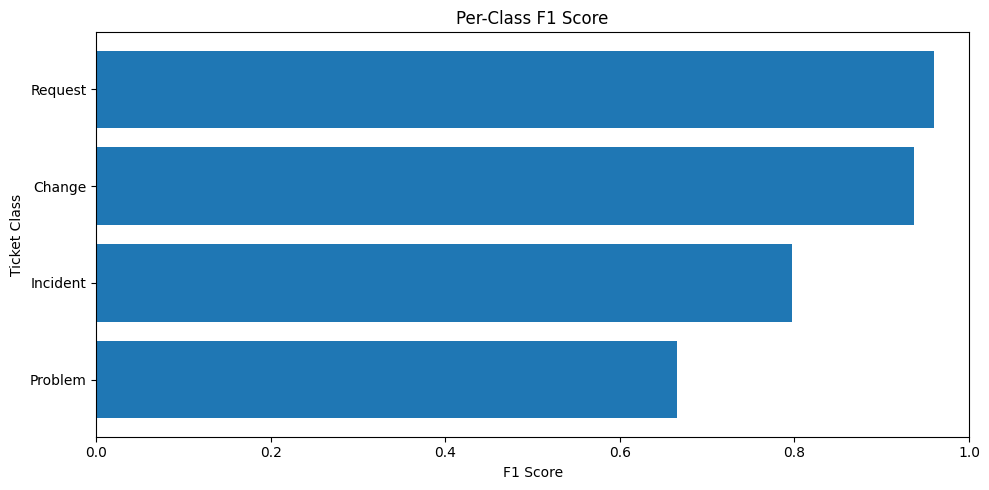

,precision,recall,f1-score,support
Problem,0.616095,0.723982,0.665696,2210.0
Incident,0.841107,0.758015,0.797402,4211.0
Change,0.924866,0.950368,0.937443,1088.0
Request,0.960439,0.960120,0.960279,3009.0


In [48]:
# ============================================================
# Per-class F1 score visualization
# ============================================================

per_class_report = report_df.copy()

# Keep only real class rows
per_class_report = per_class_report[
    ~per_class_report.index.isin(["accuracy", "macro avg", "weighted avg"])
].copy()

per_class_report = per_class_report.sort_values("f1-score", ascending=True)

plt.figure(figsize=(10, max(5, len(per_class_report) * 0.35)))
plt.barh(per_class_report.index, per_class_report["f1-score"])
plt.title("Per-Class F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Ticket Class")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

display(per_class_report[["precision", "recall", "f1-score", "support"]].sort_values("f1-score"))

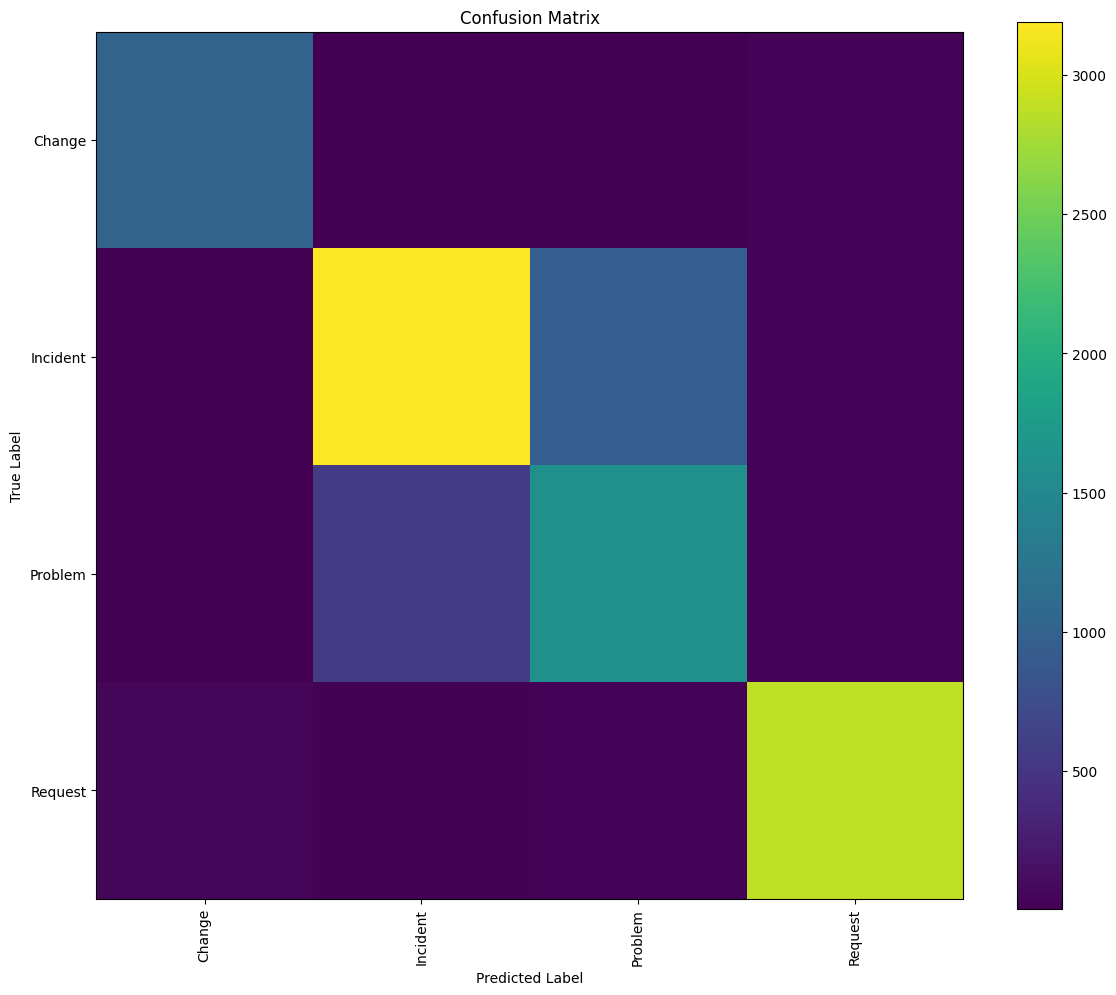

In [49]:
# ============================================================
# Confusion matrix visualization
# ============================================================

labels_sorted = sorted(y_test.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(labels_sorted))
plt.xticks(tick_marks, labels_sorted, rotation=90)
plt.yticks(tick_marks, labels_sorted)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

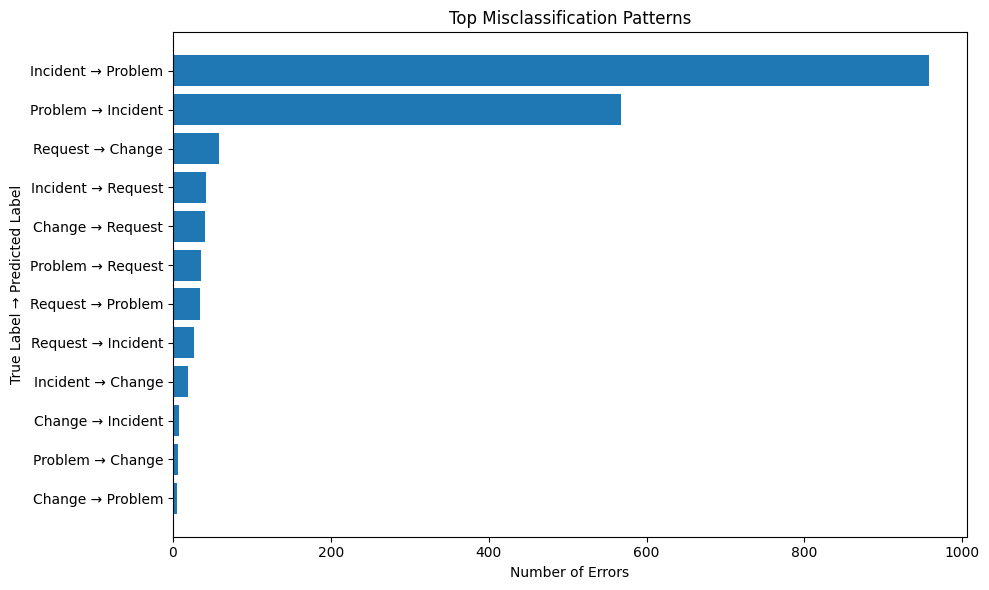

,true_label,predicted_label,count,pair
4,Incident,Problem,958,Incident → Problem
7,Problem,Incident,568,Problem → Incident
9,Request,Change,59,Request → Change
5,Incident,Request,42,Incident → Request
2,Change,Request,41,Change → Request
8,Problem,Request,36,Problem → Request
11,Request,Problem,34,Request → Problem
10,Request,Incident,27,Request → Incident
3,Incident,Change,19,Incident → Change
0,Change,Incident,8,Change → Incident


In [50]:
# ============================================================
# Most confused class pairs visualization
# ============================================================

confusion_pairs = (
    misclassified_df
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

confusion_pairs["pair"] = (
    confusion_pairs["true_label"].astype(str)
    + " → "
    + confusion_pairs["predicted_label"].astype(str)
)

top_confusions = confusion_pairs.head(15).sort_values("count")

plt.figure(figsize=(10, 6))
plt.barh(top_confusions["pair"], top_confusions["count"])
plt.title("Top Misclassification Patterns")
plt.xlabel("Number of Errors")
plt.ylabel("True Label → Predicted Label")
plt.tight_layout()
plt.show()

display(confusion_pairs.head(20))

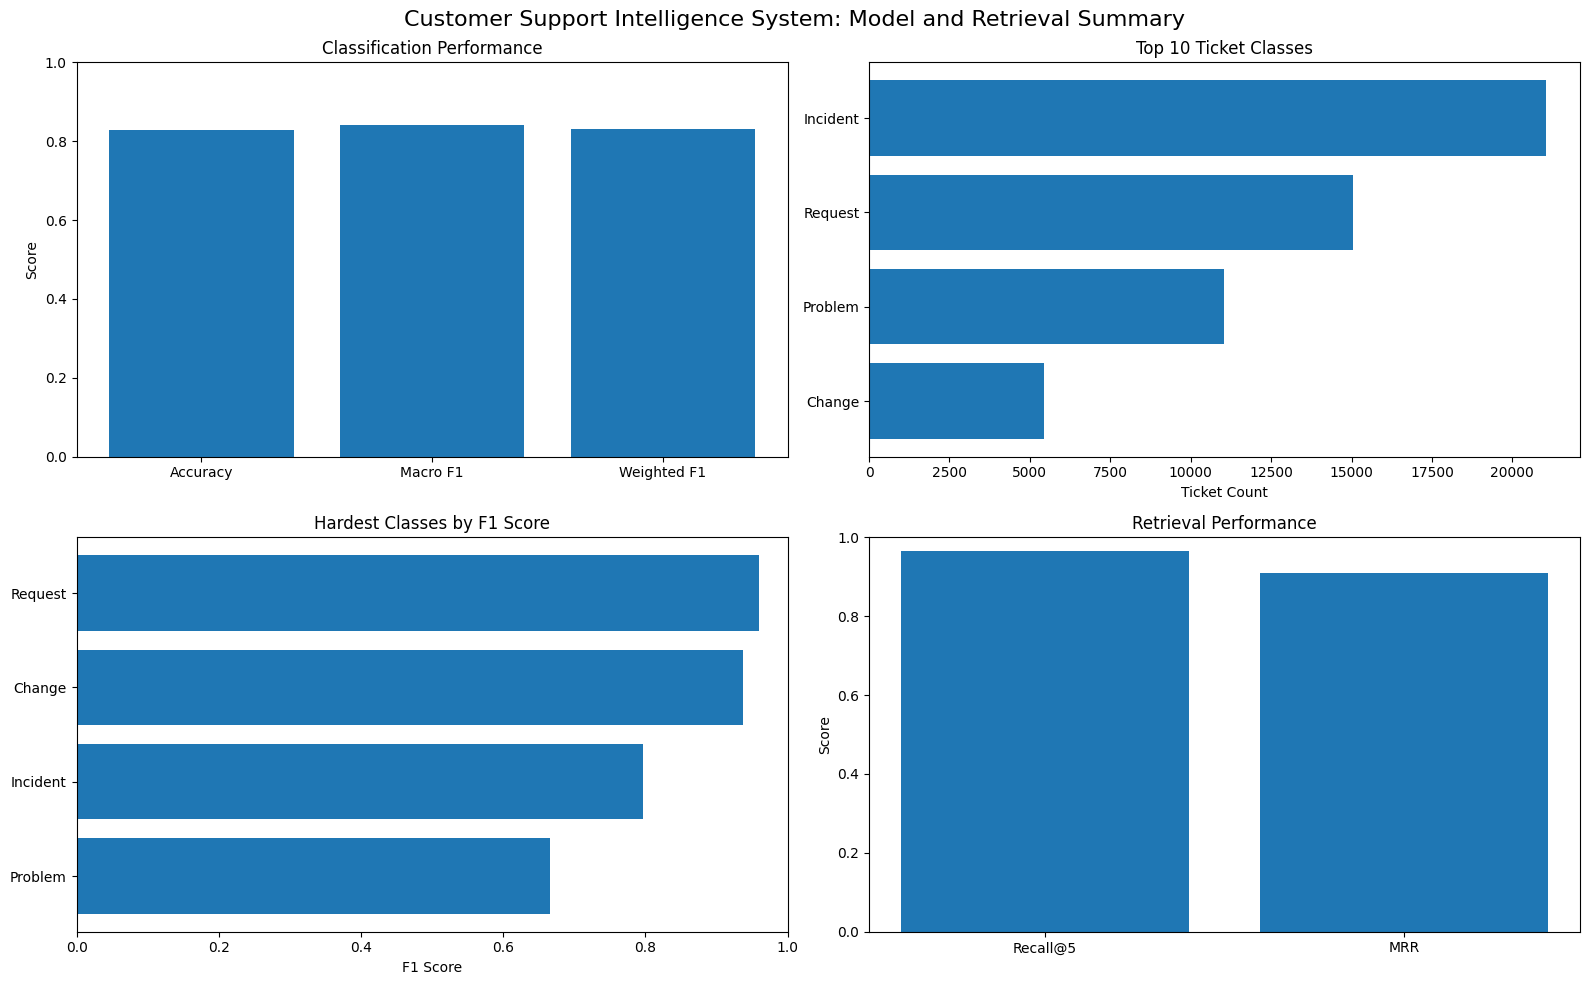

In [51]:
# ============================================================
# Final ML project visualization summary
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Classification metrics
metrics_df = pd.DataFrame({
    "metric": ["Accuracy", "Macro F1", "Weighted F1"],
    "score": [accuracy, macro_f1, weighted_f1]
})

axes[0, 0].bar(metrics_df["metric"], metrics_df["score"])
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title("Classification Performance")
axes[0, 0].set_ylabel("Score")

# 2. Top class distribution
top_classes = work_df["label"].value_counts().head(10).sort_values()
axes[0, 1].barh(top_classes.index.astype(str), top_classes.values)
axes[0, 1].set_title("Top 10 Ticket Classes")
axes[0, 1].set_xlabel("Ticket Count")

# 3. Per-class F1
per_class_report = report_df.copy()
per_class_report = per_class_report[
    ~per_class_report.index.isin(["accuracy", "macro avg", "weighted avg"])
].copy()
bottom_f1 = per_class_report.sort_values("f1-score").head(10)

axes[1, 0].barh(bottom_f1.index.astype(str), bottom_f1["f1-score"])
axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_title("Hardest Classes by F1 Score")
axes[1, 0].set_xlabel("F1 Score")

# 4. Retrieval metrics
retrieval_metrics_df = pd.DataFrame({
    "metric": [k for k in retrieval_metrics.keys() if k != "evaluated_queries"],
    "score": [v for k, v in retrieval_metrics.items() if k != "evaluated_queries"]
})

axes[1, 1].bar(retrieval_metrics_df["metric"], retrieval_metrics_df["score"])
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title("Retrieval Performance")
axes[1, 1].set_ylabel("Score")

plt.suptitle("Customer Support Intelligence System: Model and Retrieval Summary", fontsize=16)
plt.tight_layout()
plt.show()

In [52]:
risk_report = assess_rag_risk(rag_result)

,signal,value
0,Top Retrieval Score,0.343957
1,Classification Confidence,0.583721


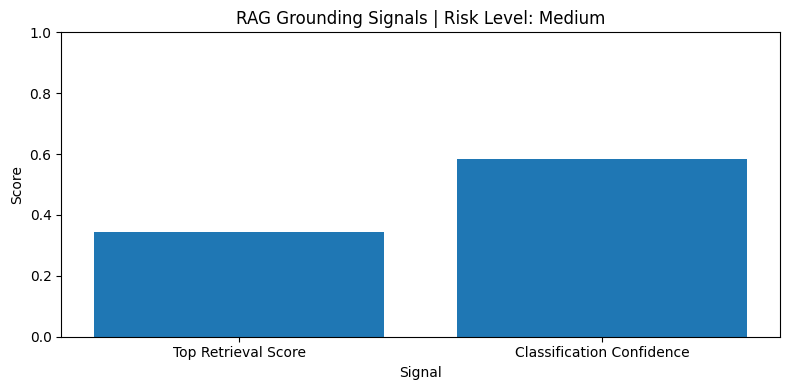

Risk level: Medium
Risks: ['Low retrieval similarity score']


In [53]:
# ============================================================
# RAG risk and confidence visualization
# ============================================================

risk_visual_df = pd.DataFrame({
    "signal": ["Top Retrieval Score", "Classification Confidence"],
    "value": [
        risk_report.get("top_retrieval_score", 0),
        risk_report.get("classification_confidence", 0)
        if risk_report.get("classification_confidence") is not None
        else 0
    ]
})

display(risk_visual_df)

plt.figure(figsize=(8, 4))
plt.bar(risk_visual_df["signal"], risk_visual_df["value"])
plt.ylim(0, 1)
plt.title(f"RAG Grounding Signals | Risk Level: {risk_report['risk_level']}")
plt.xlabel("Signal")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

print("Risk level:", risk_report["risk_level"])
print("Risks:", risk_report["risks"])

,metric,score
0,Recall@5,0.966000
1,MRR,0.909833


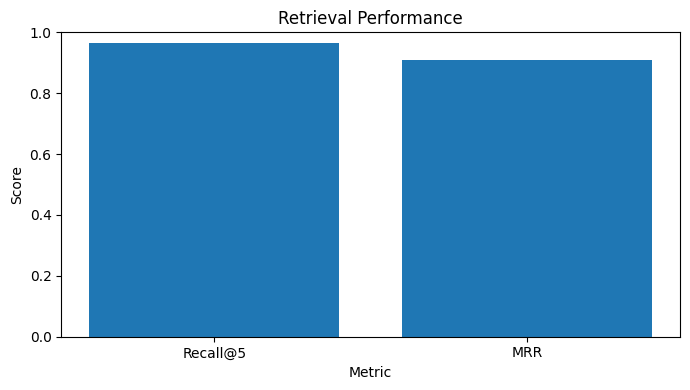

Evaluated queries: 500


In [54]:
# ============================================================
# Retrieval metrics visualization
# ============================================================

retrieval_metrics_df = pd.DataFrame({
    "metric": [k for k in retrieval_metrics.keys() if k != "evaluated_queries"],
    "score": [v for k, v in retrieval_metrics.items() if k != "evaluated_queries"]
})

display(retrieval_metrics_df)

plt.figure(figsize=(7, 4))
plt.bar(retrieval_metrics_df["metric"], retrieval_metrics_df["score"])
plt.ylim(0, 1)
plt.title("Retrieval Performance")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

print("Evaluated queries:", retrieval_metrics.get("evaluated_queries"))

In [55]:
search_results = semantic_search(sample_query, top_k=5)

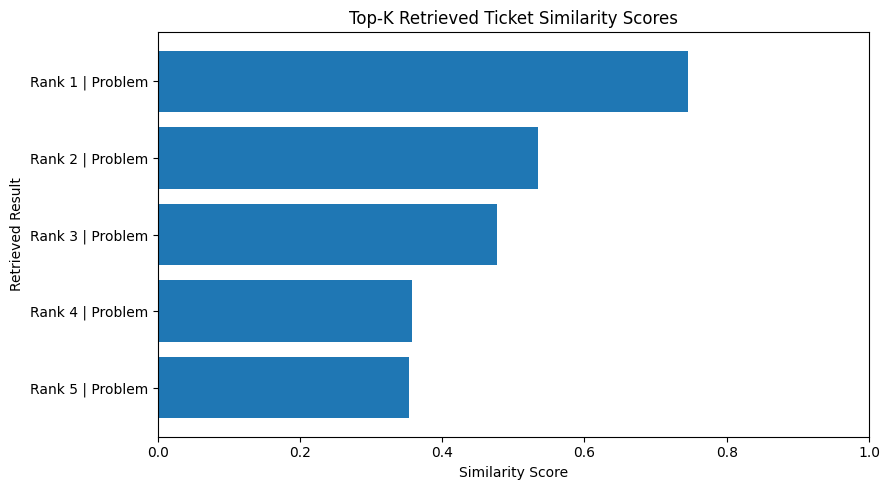

,rank,score,label,ticket_text,support_answer
0,1,0.746232,Problem,Issues with Investment Forecast Accuracy I am ...,"Dear <name>, thank you for bringing the issues..."
1,2,0.534140,Problem,Investment Forecasts Have Inaccuracies I am co...,"Dear <name>, thank you for bringing the inaccu..."
2,3,0.477357,Problem,Accuracy Issues with Investment Forecasts I ha...,"Dear <name>, we appreciate you bringing this i..."
3,4,0.357712,Problem,Discrepancies in Investment Forecasts Detected...,We will reassess and modernize our models to o...
4,5,0.353303,Problem,Detected Inaccuracies in Investment Forecasts ...,We will reassess and modernize our models to e...


In [56]:
# ============================================================
# Retrieval score visualization
# ============================================================

retrieval_plot_df = search_results.copy()
retrieval_plot_df["result"] = (
    "Rank "
    + retrieval_plot_df["rank"].astype(str)
    + " | "
    + retrieval_plot_df["label"].astype(str)
)

plt.figure(figsize=(9, 5))
plt.barh(
    retrieval_plot_df["result"][::-1],
    retrieval_plot_df["score"][::-1]
)
plt.title("Top-K Retrieved Ticket Similarity Scores")
plt.xlabel("Similarity Score")
plt.ylabel("Retrieved Result")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

display(search_results[["rank", "score", "label", "ticket_text", "support_answer"]])

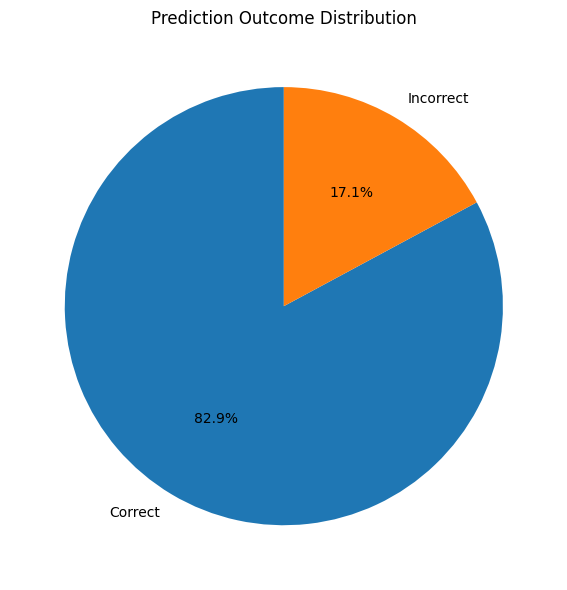

,count
is_correct,
Correct,8715
Incorrect,1803


In [57]:
# ============================================================
# Correct vs incorrect prediction visualization
# ============================================================

prediction_counts = error_df["is_correct"].map({
    True: "Correct",
    False: "Incorrect"
}).value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    prediction_counts.values,
    labels=prediction_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Prediction Outcome Distribution")
plt.tight_layout()
plt.show()

display(prediction_counts.to_frame("count"))